## 004 - AppleCider images
<a id='index'></a> <br>

In [1]:
import os
import sys
sys.path.insert(0, 'AppleCider')

## so many plots
import AppleCider.preprocess.plot_data as plot_data
import AppleCider.preprocess.more_info as more_info
from AppleCider.preprocess.plot_data import plot_dataset

import AppleCider.core.drink as drink

import wandb
import joblib
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import pickle
from datetime import datetime

from AppleCider.core.dataset import DataGenerator

In [2]:
CLASSES = ['SN Ia', 'SN II', 'SN IIP', 'Cataclysmic', 'AGN', 'SN IIn', 'SN Ic', 'SN Ib', 'SN IIb', 'Tidal Disruption Event']
data_dir = '/SEDM_folder'

SEDM_dataset = pd.read_csv('/csv-pkl/SEDM_BrightTransientSurvey.csv')

In [3]:
config = {
        'project': 'AppleCider',
        'mode': 'image',    # 'clip' 'photo' 'spectra' 'meta' 'image' 'all'
        'config_from': None,    # 'meridk/AstroCLIPResults/d2u52yml',
        'random_seed': 42,  # 42, 66, 0, 12, 123
        'use_wandb': True,
        'save_weights': False,
        'weights_path': f'AppleCider/weights/images/{datetime.now().strftime("%Y-%m-%d-%H-%M")}',
        'use_pretrain': None,
        'freeze': False,

        # Data General
        'preprocessed_path':'/data_train_BTS/',
        'df_path': '/csv-pkl/data_train_BTS.csv',
        
        # save train, val file names ...
        'train_files_path': '/csv-pkl/train_files_BTS.pkl',
        'val_files_path': '/csv-pkl/val_files_BTS.pkl',
        'generate_train_val_files': False,
        
        'step': 'type',
        'classes': CLASSES,
        'group_labels': False,
        'max_samples': 5000,
        'num_classes': len(CLASSES),

        # Photometry Model
        'seq_len': 230,
        'p_enc_in': 4,
        'p_d_model': 128,
        'p_dropout': 0.2,
        'p_factor': 1,
        'p_output_attention': False,
        'p_n_heads': 12,
        'p_d_ff': 512,
        'p_activation': 'gelu',
        'p_e_layers': 8,

        # Spectra Model
        's_dropout': 0.2,
        's_conv_channels': [1, 64, 64, 32, 32],
        's_kernel_size': 3,
        's_mp_kernel_size': 4,

        # Metadata Model
        'm_hidden_dim': 512,
        'm_dropout': 0.2,
        # TODO use actual column names
        'meta_cols': range(10),
        'scaler_path': '/csv-pkl/scaler_BTS.pkl',

        # Image Model
        'input_channels': 3,
        'conv1_channels': 64,
        'conv2_channels': 16,
        'conv_kernel': 3,
        'conv_dropout1': 0.45,
        'conv_dropout2': 0.65,

        # MultiModal Model
        'hidden_dim': 512,
        'fusion': 'avg',  # 'avg', 'concat'

        # Training
        'batch_size': 512,
        'lr': 0.001,
        'beta1': 0.9,
        'beta2': 0.999,
        'weight_decay': 0.01,
        'epochs':30,
        'early_stopping_patience': 25,
        'scheduler': 'ReduceLROnPlateau',  # 'ExponentialLR', 'ReduceLROnPlateau'
        'gamma': 0.9,  # for ExponentialLR scheduler
        'factor': 0.3,  # for ReduceLROnPlateau scheduler
        'patience': 3,  # for ReduceLROnPlateau scheduler
        'warmup': False,
        'warmup_epochs': 100,
        'clip_grad': False,
        'clip_value': 5
    }


In [4]:
train_dataset = DataGenerator(config=config, split='train')

image: 
 tensor([[[ 0.0143,  0.0146,  0.0159,  ...,  0.0160,  0.0144,  0.0136],
         [ 0.0172,  0.0164,  0.0161,  ...,  0.0179,  0.0171,  0.0160],
         [ 0.0150,  0.0165,  0.0156,  ...,  0.0155,  0.0165,  0.0147],
         ...,
         [ 0.0160,  0.0158,  0.0150,  ...,  0.0165,  0.0157,  0.0151],
         [ 0.0160,  0.0148,  0.0140,  ...,  0.0143,  0.0135,  0.0156],
         [ 0.0161,  0.0166,  0.0149,  ...,  0.0158,  0.0157,  0.0153]],

        [[ 0.0156,  0.0156,  0.0156,  ...,  0.0153,  0.0155,  0.0156],
         [ 0.0159,  0.0154,  0.0153,  ...,  0.0159,  0.0158,  0.0154],
         [ 0.0156,  0.0155,  0.0155,  ...,  0.0158,  0.0156,  0.0155],
         ...,
         [ 0.0156,  0.0159,  0.0157,  ...,  0.0160,  0.0156,  0.0156],
         [ 0.0155,  0.0155,  0.0157,  ...,  0.0161,  0.0157,  0.0156],
         [ 0.0157,  0.0155,  0.0158,  ...,  0.0159,  0.0157,  0.0155]],

        [[-0.0111, -0.0058,  0.0060,  ...,  0.0078, -0.0080, -0.0173],
         [ 0.0181,  0.0123,  0.0090,

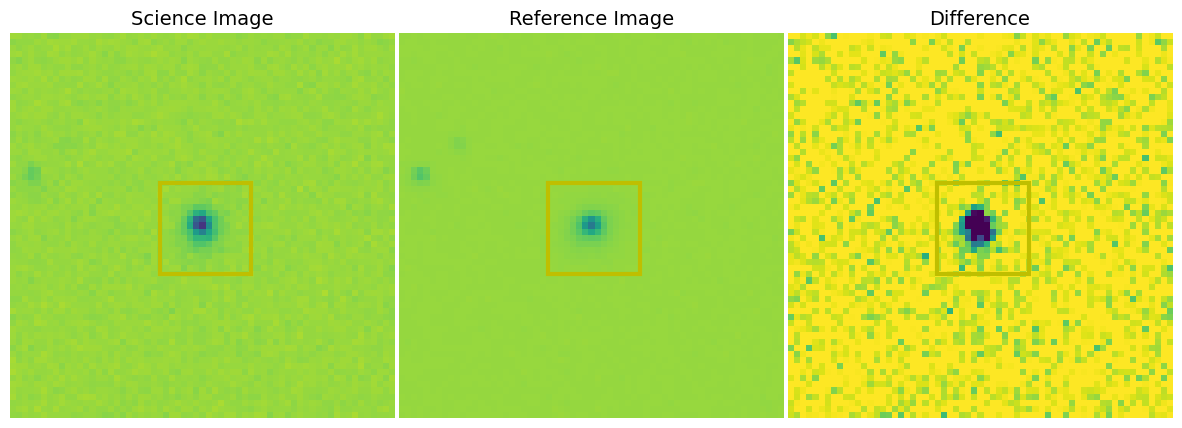

In [13]:
from AppleCider.preprocess.plot_data import plot_images
plot_images.plot_image_tensor(train_dataset[2][2])

In [ ]:
wandb.init(
    project=config['project'])

In [ ]:
drink.run(config)

Using cpu


Train:   0%|          | 0/12 [00:00<?, ?it/s]